In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

In [ ]:
# List of paths with .csv files
folder_names  = [
        "/mnt/c/users/helen/Desktop/WT_new",
        "/mnt/c/users/helen/Desktop/As_2h_new",
        "/mnt/c/users/helen/Desktop/As_4h_new",
]

folders = [Path(f) for f in folder_names]

In [2]:
# List of paths with .csv files
folder_names  = [
        "/mnt/c/users/helen/Desktop/WT_cyt",
        "/mnt/c/users/helen/Desktop/PDS_5uM_cyt",
        "/mnt/c/users/helen/Desktop/PDS_20uM_cyt",
]

folders = [Path(f) for f in folder_names]

In [ ]:
# Data loading into single dataframe
dfs = []

for folder in folders:
    for file in folder.glob("*.csv"):

        df = pd.read_csv(file)

        # Add file name column
        df["file_name"] = file.stem

        dfs.append(df)

    # Combine all dataframes
    data = pd.concat(dfs, ignore_index=True)

    # Column ordering
    data = data[
        ["file_name", "ROI", "Area", "Mean"]
    ]

    # Rename ROI column to remove the suffix after the underscore
    data["ROI"] = data["ROI"].apply(lambda x: x.split("_")[0])
    
# Add new sample_name column
data['sample_name'] = data['file_name'].apply(lambda x: 'WT' if 'NO_AS' in x else ('PDS_20uM' if '20uM' in x else 'PDS_5uM'))

In [12]:
# Optional: Save the combined dataframe to a new CSV file
data.to_csv("/mnt/c/users/helen/Desktop/combined_data.csv", index=False, sep=";", decimal=",")

In [10]:
data['file_name'][154]

'C2_3_MP_U2OS_fixed_WT_PDS_4h_20uM.nd2_(series_04)_rois'

In [ ]:
# Filtration of outliters
#data = data[data['Mean'] < 20]

# Optional: Save the combined filtered dataframe to a new CSV file
#data.to_csv("/mnt/c/users/helen/Desktop/combined_data_filtered.csv", index=False, sep=";", decimal=",")

In [13]:
# Brief statistical summary of the data
data.groupby(['sample_name', 'ROI']).agg({'Area': ['mean', 'std', 'count'], 'Mean': ['mean', 'std']})

Area                        Mean          
                             mean         std count      mean       std
sample_name ROI                                                        
PDS_20uM    Cytoplasm  681.945100  333.981185    10  0.641500  0.819739
            Nucleus    267.675600   52.825718    10  3.257300  3.403056
            Whole      949.620800  336.630680    10  1.339400  1.207716
PDS_5uM     Cytoplasm  514.910842  210.405497    19  0.842053  0.610578
            Nucleus    255.957684   79.078199    19  5.825632  4.206685
            Whole      770.089000  236.785260    19  2.462842  1.609400
WT          Cytoplasm  480.415609  329.606003    23  1.024174  0.659224
            Nucleus    254.004000   70.747867    23  5.265130  3.429101
            Whole      733.317174  355.925324    23  2.687739  1.920731

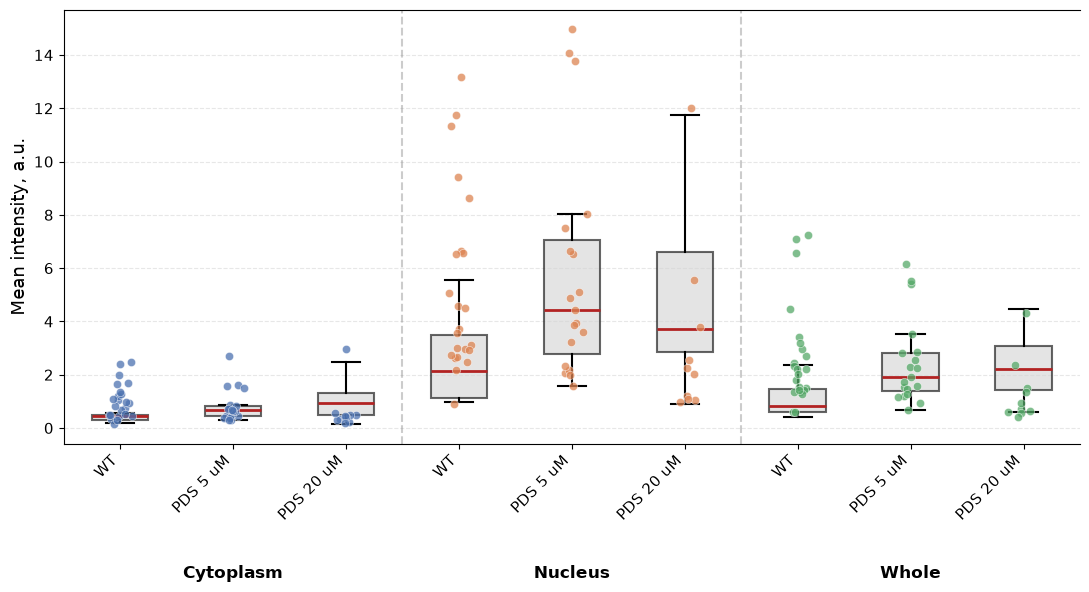

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

# Order of groups
roi_order = ["Cytoplasm", "Nucleus", "Whole"]
sample_order = ["WT", "PDS_5uM", "PDS_20uM"]

# Your custom sample names for x-axis
sample_labels = {
    "WT": "WT",
    "PDS_5uM": "PDS 5 uM",
    "PDS_20uM": "PDS 20 uM",
}

# -------------------------------------------------------
# Color boxes according to ROI
# -------------------------------------------------------
roi_colors = {
    "Cytoplasm": "#4C72B0",   # blue
    "Nucleus": "#DD8452",     # orange
    "Whole": "#55A868",       # green
}

# Prepare data in desired order
groups = []
labels = []
positions = []

pos = 1
for roi in roi_order:
    for sample in sample_order:
        values = data.loc[
            (data["ROI"] == roi) & (data["sample_name"] == sample),
            "Mean"
        ].dropna()

        groups.append(values)
        labels.append(sample_labels[sample])
        positions.append(pos)
        pos += 1


# -------------------------------------------------------
# Boxplots: all light gray
# -------------------------------------------------------
data.boxplot(
    column="Mean",
    by=["ROI", "sample_name"],
    ax=ax,
    grid=False,
    showfliers=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightgray",
                  edgecolor="black",
                  linewidth=1.5,
                  alpha=0.6),
    medianprops=dict(color="firebrick", linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
)


# -------------------------------------------------------
# Overlay individual points
# -------------------------------------------------------
for i, (roi, sample) in enumerate(
    [(roi, sample) for roi in roi_order for sample in sample_order],
    start=1
):
    values = data.loc[
        (data["ROI"] == roi) & (data["sample_name"] == sample),
        "Mean"
    ].dropna()

    x = np.random.normal(i, 0.05, len(values))

    ax.scatter(
        x,
        values,
        color=roi_colors[roi],
        edgecolor="white",
        linewidth=0.4,
        s=35,
        alpha=0.75,
        zorder=3,
    )
    
# X-axis sample labels
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

# ROI subgroup names below x-axis
roi_centers = {
    "Cytoplasm": 2,
    "Nucleus": 5,
    "Whole": 8,
}

for roi, center in roi_centers.items():
    ax.text(
        center,
        -0.28,
        roi,
        ha="center",
        va="top",
        transform=ax.get_xaxis_transform(),
        fontsize=12,
        fontweight="bold",
    )
    
# Optional vertical separators between ROIs
ax.axvline(3.5, color="gray", linestyle="--", alpha=0.4)
ax.axvline(6.5, color="gray", linestyle="--", alpha=0.4)
    
# Appearance
ax.set_ylabel("Mean intensity, a.u.", fontsize=13)
ax.set_xlabel("")


# Improve appearance
fig.suptitle("")
ax.set_title("")
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)
ax.yaxis.grid(True, linestyle="--", alpha=0.3)

plt.subplots_adjust(bottom=0.28)
plt.tight_layout()

# Optional: Save the figure to a file
plt.savefig("/mnt/c/users/helen/Desktop/boxplot.png", dpi=600, bbox_inches="tight")

# Show image
plt.show()

In [ ]:
# Statistics - Mann-Whitney U test

roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", "Sodium_arsenite_2h"),
    ("WT", "Sodium_arsenite_4h"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        u, p = mannwhitneyu(x, y, alternative="two-sided")

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "U statistic": u,
            "p-value": p,
        })

stats_df = pd.DataFrame(results)

stats_df

In [ ]:
# Optional: Save dataframe to a new CSV file
stats_df.to_csv("/mnt/c/users/helen/Desktop/u_test_results.csv", index=False, sep=";", decimal=",")

# Statistics

## t-test

In [15]:
# Statistics - T test
roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", 'PDS_5uM'),
    ("WT", "PDS_20uM"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        t, p = ttest_ind(x, y, equal_var=False)

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "t statistic": t,
            "p-value": p,
        })

ttest_df = pd.DataFrame(results)

ttest_df

,ROI,Group 1,Group 2,n1,n2,t statistic,p-value
0,Cytoplasm,WT,PDS_5uM,23,19,0.927983,0.359061
1,Cytoplasm,WT,PDS_20uM,23,10,1.304211,0.212750
2,Nucleus,WT,PDS_5uM,23,19,-0.466659,0.643666
3,Nucleus,WT,PDS_20uM,23,10,1.554018,0.138262
4,Whole,WT,PDS_5uM,23,19,0.412864,0.681912
5,Whole,WT,PDS_20uM,23,10,2.436438,0.021832


In [16]:
# Optional: Save dataframe to a new CSV file
ttest_df.to_csv("/mnt/c/users/helen/Desktop/t_test_results.csv", index=False, sep=";", decimal=",")

## U-test

In [19]:
roi_order = ["Cytoplasm", "Nucleus", "Whole"]

comparisons = [
    ("WT", 'PDS_5uM'),
    ("WT", "PDS_20uM"),
]

results = []

for roi in roi_order:
    roi_data = data[data["ROI"] == roi]

    for g1, g2 in comparisons:
        x = roi_data.loc[roi_data["sample_name"] == g1, "Mean"]
        y = roi_data.loc[roi_data["sample_name"] == g2, "Mean"]

        u, p = mannwhitneyu(x, y)

        results.append({
            "ROI": roi,
            "Group 1": g1,
            "Group 2": g2,
            "n1": len(x),
            "n2": len(y),
            "t statistic": t,
            "p-value": p,
        })

utest_df = pd.DataFrame(results)

utest_df

,ROI,Group 1,Group 2,n1,n2,t statistic,p-value
0,Cytoplasm,WT,PDS_5uM,23,19,2.041055,0.294283
1,Cytoplasm,WT,PDS_20uM,23,10,2.041055,0.021927
2,Nucleus,WT,PDS_5uM,23,19,2.041055,0.781030
3,Nucleus,WT,PDS_20uM,23,10,2.041055,0.029697
4,Whole,WT,PDS_5uM,23,19,2.041055,0.742520
5,Whole,WT,PDS_20uM,23,10,2.041055,0.010293


In [ ]:
# Optional: Save dataframe to a new CSV file
utest_df.to_csv("/mnt/c/users/helen/Desktop/u_test_results.csv", index=False, sep=";", decimal=",")